In [25]:
"""
SVM Pipeline for Throughput and Response Time Prediction
(Optimized using 90th Percentile Absolute Percentage Error)
"""

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from scipy.stats import loguniform


df_train = pd.read_csv('ram.csv')
df_test = pd.read_csv('testram.csv')

input_features = ['ArrivalRate', 'device_write', 'cpus', 'memory', 'size', 'cpuLoad']
output_targets = ['Throughput', 'ResponseTime']

def convert_memory(mem_str):
    mem_str = str(mem_str).lower()
    if 'g' in mem_str:
        return float(mem_str.replace('g', '')) * 1024
    elif 'm' in mem_str:
        return float(mem_str.replace('m', ''))
    return float(mem_str)

def preprocess(df):
    df = df[input_features + output_targets].copy()
    df = df.dropna(subset=output_targets)

    df['device_write_numeric'] = df['device_write'].str.replace('mb', '').astype(float)
    df['memory_numeric'] = df['memory'].apply(convert_memory)

    df = df[df['Throughput'] != 0]

    return df

train = preprocess(df_train)
test = preprocess(df_test)


# Log transform response time
train['ResponseTime_log'] = np.log1p(train['ResponseTime'])
test['ResponseTime_log'] = np.log1p(test['ResponseTime'])

# Features
X_cols = ['ArrivalRate', 'cpus', 'size', 'cpuLoad',
          'device_write_numeric', 'memory_numeric']

X_train = train[X_cols].values
X_test = test[X_cols].values

# Targets
y_tp_train = train['Throughput'].values
y_tp_test = test['Throughput'].values

y_rt_train_log = train['ResponseTime_log'].values
y_rt_test_log = test['ResponseTime_log'].values

def p90_ape(y_true, y_pred):
    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100
    return np.percentile(pct_err, 90)

p90_scorer = make_scorer(p90_ape, greater_is_better=False)


svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf'))
])

param_dist = {
    'svr__C': loguniform(1e-2, 1e3),
    'svr__epsilon': loguniform(1e-3, 1),
    'svr__gamma': ['scale', 'auto']
}

def tune_model(X, y, name):
    print(f"\nTuning {name} (P90 APE)...")

    search = RandomizedSearchCV(
        svm_pipeline,
        param_distributions=param_dist,
        n_iter=20,
        cv=3,
        scoring=p90_scorer,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    search.fit(X, y)

    print("Best params:", search.best_params_)
    print("Best CV P90 APE:", -search.best_score_)

    return search.best_estimator_


model_tp = tune_model(X_train, y_tp_train, "Throughput")
model_rt = tune_model(X_train, y_rt_train_log, "Response Time")


def evaluate(y_true, y_pred, name):
    pct_err = np.abs((y_true - y_pred) / (y_true + 1e-6)) * 100

    p90 = np.percentile(pct_err, 90)
    mape = np.mean(pct_err)
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)

    acc_10 = (pct_err <= 10).mean() * 100
    acc_20 = (pct_err <= 20).mean() * 100
    acc_50 = (pct_err <= 50).mean() * 100
    acc_90 = (pct_err <= 90).mean() * 100

    print(f"\n{name} RESULTS")
    print("-" * 40)
    print(f"P90 APE:        {p90:.2f}%  PRIMARY METRIC")
    print(f"MAPE:           {mape:.2f}%")
    print(f"SMAPE:          {smape:.4f}")
    print(f"RMSE:           {rmse:.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"R²:             {r2:.4f}")
    print(f"Acc ≤10%:       {acc_10:.2f}%")
    print(f"Acc ≤20%:       {acc_20:.2f}%")
    print(f"Acc ≤50%:       {acc_50:.2f}%")
    print(f"Acc ≤90%:       {acc_90:.2f}%")
    

# Throughput
y_tp_pred = model_tp.predict(X_test)

# Response Time (log → original)
y_rt_pred_log = model_rt.predict(X_test)
y_rt_pred = np.expm1(y_rt_pred_log)
y_rt_true = np.expm1(y_rt_test_log)

evaluate(y_tp_test, y_tp_pred, "THROUGHPUT")
evaluate(y_rt_true, y_rt_pred, "RESPONSE TIME")



Tuning Throughput (P90 APE)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'svr__C': np.float64(20.54051942538844), 'svr__epsilon': np.float64(0.00861257919259488), 'svr__gamma': 'auto'}
Best CV P90 APE: 103.58201283959609

Tuning Response Time (P90 APE)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'svr__C': np.float64(10.90747583515769), 'svr__epsilon': np.float64(0.0032476735706274485), 'svr__gamma': 'scale'}
Best CV P90 APE: 107.34863678064231

THROUGHPUT RESULTS
----------------------------------------
P90 APE:        70.18%  PRIMARY METRIC
MAPE:           39.89%
SMAPE:          0.3324
RMSE:           5.4281
MAE:            4.5276
R²:             -1.6525
Acc ≤10%:       10.00%
Acc ≤20%:       36.67%
Acc ≤50%:       66.67%
Acc ≤90%:       93.33%

RESPONSE TIME RESULTS
----------------------------------------
P90 APE:        91.82%  PRIMARY METRIC
MAPE:           136.73%
SMAPE:          0.9804
RMSE:           30829.1927

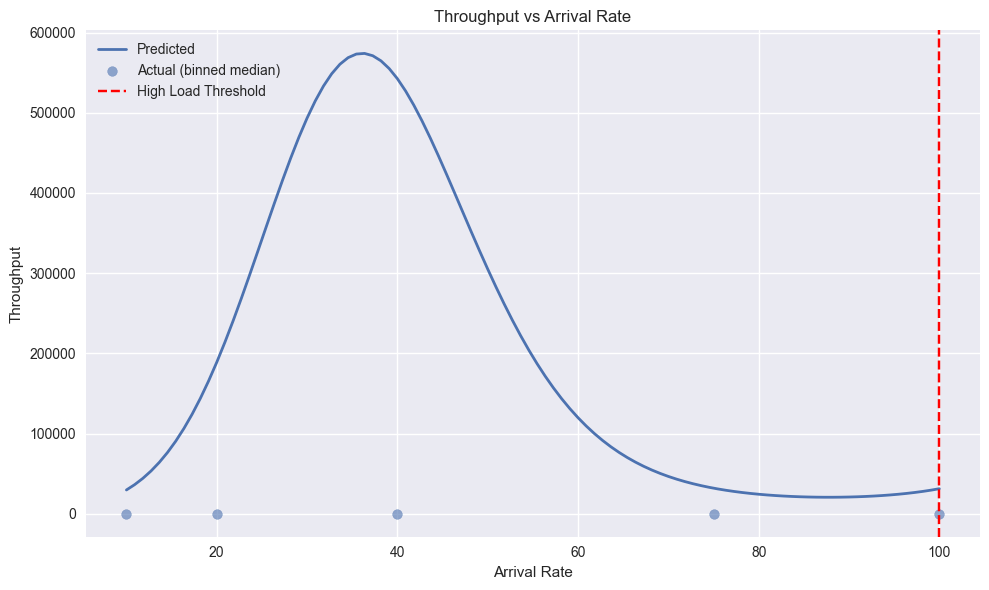

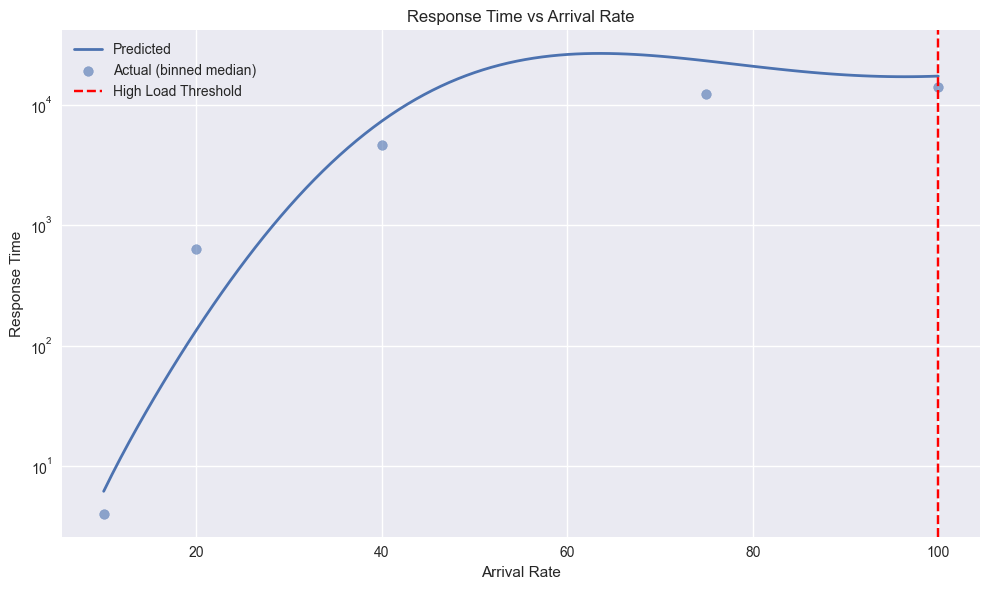

In [26]:
"""
Arrival Rate Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_arrival_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    arrival_range = np.linspace(
        df['ArrivalRate'].min(),
        df['ArrivalRate'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['ArrivalRate'] = arrival_range

    return arrival_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin arrival rate to smooth curve
    df['Arrival_bin'] = pd.cut(df['ArrivalRate'], bins=bins)

    grouped = (
        df.groupby('Arrival_bin')[['ArrivalRate', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['ArrivalRate'], grouped


arrival_range, X_sweep = create_arrival_sweep(train, X_cols)
arrival_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Throughput")
plt.title("Throughput vs Arrival Rate")

# Optional: mark high-load region
plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('svm_throughput_vs_arrival_rate.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(arrival_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    arrival_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Arrival Rate")
plt.ylabel("Response Time")
plt.title("Response Time vs Arrival Rate")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['ArrivalRate'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('svm_response_time_vs_arrival_rate.png', dpi=300)

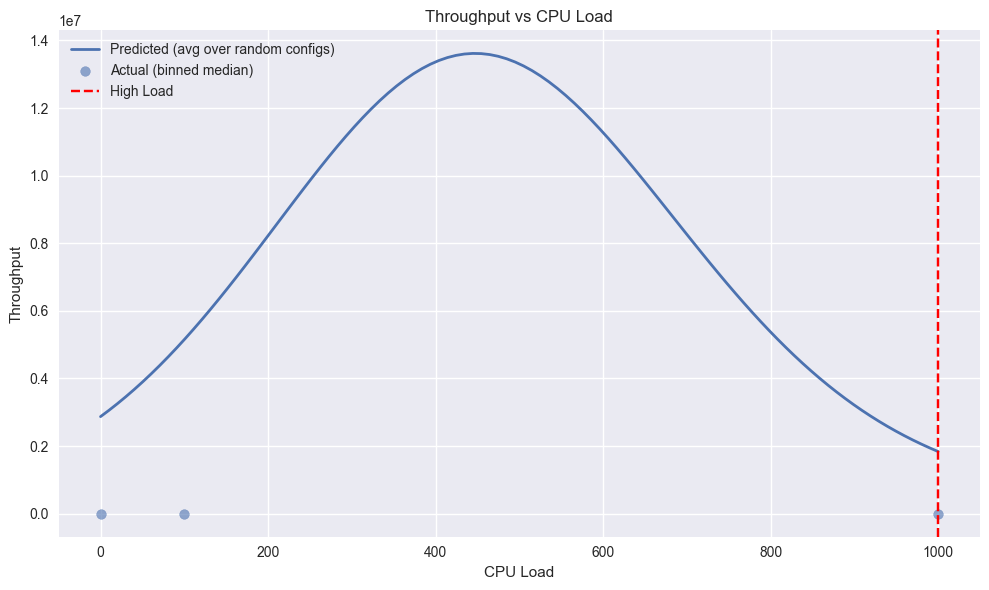

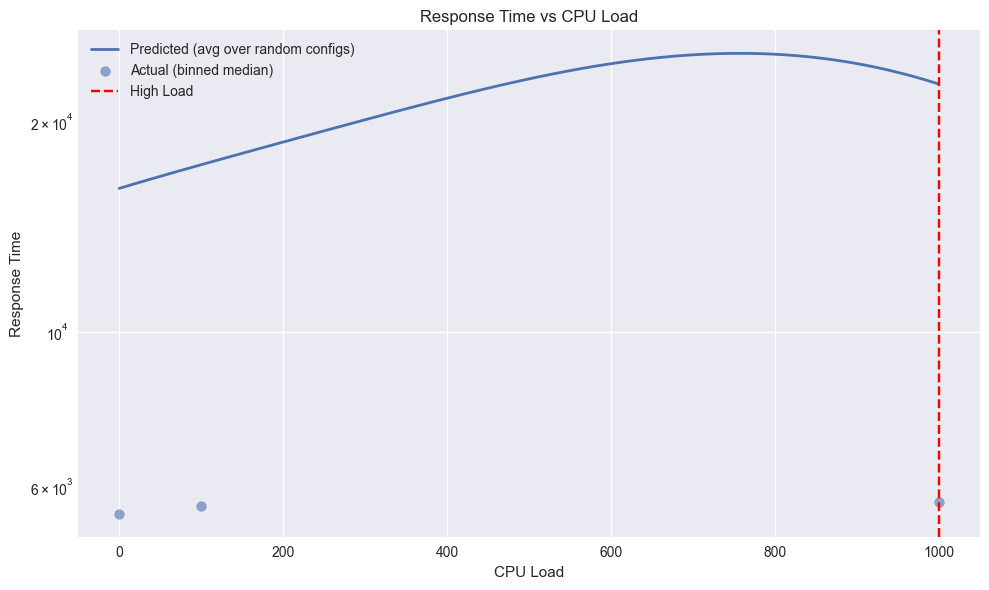

In [27]:
"""
CPU Load Sweep Visualization (Randomized, Robust)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')


def create_cpu_load_sweep(df, X_cols, n_points=100, n_samples=20):
    cpu_load_range = np.linspace(
        df['cpuLoad'].min(),
        df['cpuLoad'].max(),
        n_points
    )

    # Sample multiple random base configs
    base_samples = df[X_cols].sample(n=n_samples, random_state=42).reset_index(drop=True)

    X_sweep_list = []

    for _, row in base_samples.iterrows():
        temp = pd.DataFrame([row] * n_points)
        temp['cpuLoad'] = cpu_load_range
        X_sweep_list.append(temp)

    X_sweep = pd.concat(X_sweep_list, ignore_index=True)

    return cpu_load_range, X_sweep.values, n_samples


def get_actual_curve(df, bins=30):
    df = df.copy()

    df['cpuLoad_bin'] = pd.cut(df['cpuLoad'], bins=bins)

    grouped = (
        df.groupby('cpuLoad_bin')[['cpuLoad', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['cpuLoad'], grouped


cpu_load_range, X_sweep, n_samples = create_cpu_load_sweep(train, X_cols)

cpu_load_actual, df_actual = get_actual_curve(train)


# Throughput predictions
y_tp_pred_all = np.expm1(model_tp.predict(X_sweep))

# Response time predictions
y_rt_pred_all = np.expm1(model_rt.predict(X_sweep))


# Reshape → (samples, points)
y_tp_pred_all = y_tp_pred_all.reshape(n_samples, -1)
y_rt_pred_all = y_rt_pred_all.reshape(n_samples, -1)

# Average across random configs
y_tp_pred = y_tp_pred_all.mean(axis=0)
y_rt_pred = y_rt_pred_all.mean(axis=0)



plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_tp_pred, label='Predicted (avg over random configs)', linewidth=2)

plt.scatter(
    cpu_load_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("CPU Load")
plt.ylabel("Throughput")
plt.title("Throughput vs CPU Load")

plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('svm_throughput_vs_cpu_load.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(cpu_load_range, y_rt_pred, label='Predicted (avg over random configs)', linewidth=2)

plt.scatter(
    cpu_load_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("CPU Load")
plt.ylabel("Response Time")
plt.title("Response Time vs CPU Load")

plt.yscale('log')  # critical

plt.axvline(
    x=train['cpuLoad'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('svm_response_time_vs_cpu_load.png', dpi=300)

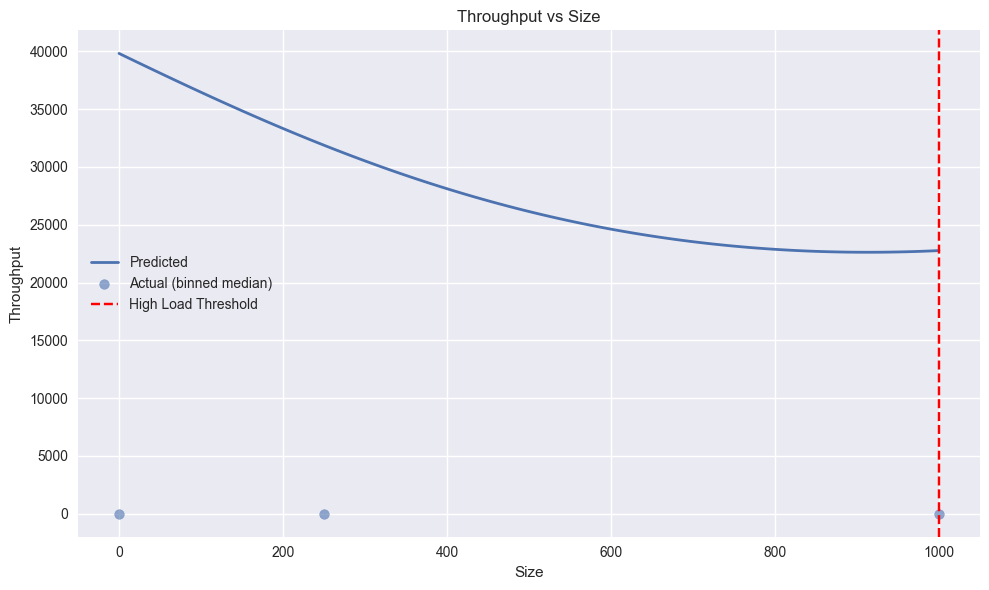

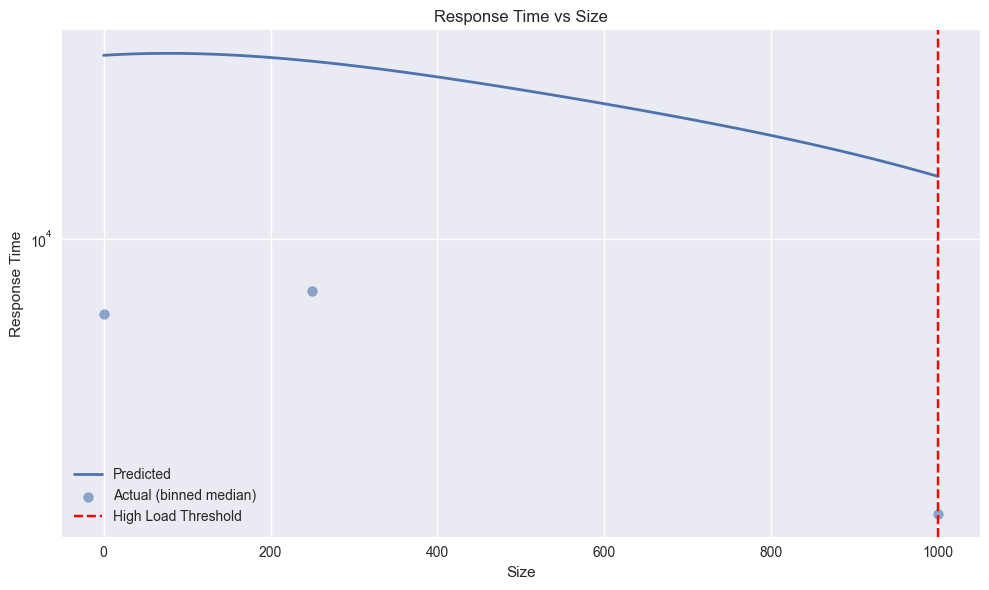

In [28]:
"""
Size Sweep Visualization
(Predicted vs Actual for Throughput and Response Time)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')



def create_size_sweep(df, X_cols, n_points=100):
    df_med = df[X_cols].median()

    size_range = np.linspace(
        df['size'].min(),
        df['size'].max(),
        n_points
    )

    X_sweep = pd.DataFrame([df_med] * n_points)
    X_sweep['size'] = size_range

    return size_range, X_sweep.values



def get_actual_curve(df, bins=30):
    df = df.copy()

    # Bin size to smooth curve
    df['Size_bin'] = pd.cut(df['size'], bins=bins)

    grouped = (
        df.groupby('Size_bin')[['size', 'Throughput', 'ResponseTime']]
        .median()
        .reset_index(drop=True)
    )

    return grouped['size'], grouped


size_range, X_sweep = create_size_sweep(train, X_cols)
size_actual, df_actual = get_actual_curve(train)


# Throughput
y_tp_pred = np.expm1(model_tp.predict(X_sweep))

# Response Time
y_rt_pred = np.expm1(model_rt.predict(X_sweep))


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_tp_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['Throughput'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Throughput")
plt.title("Throughput vs Size")

# Optional: mark high-load region
plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('svm_throughput_vs_size.png', dpi=300)


plt.figure(figsize=(10, 6))

plt.plot(size_range, y_rt_pred, label='Predicted', linewidth=2)
plt.scatter(
    size_actual,
    df_actual['ResponseTime'],
    label='Actual (binned median)',
    alpha=0.6
)

plt.xlabel("Size")
plt.ylabel("Response Time")
plt.title("Response Time vs Size")

# CRITICAL: log scale (huge dynamic range)
plt.yscale('log')

plt.axvline(
    x=train['size'].quantile(0.9),
    linestyle='--',
    color='red',
    label='High Load Threshold'
)

plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig('svm_response_time_vs_size.png', dpi=300)